### Krylov Quantum Diagonalization (KQD)

In [46]:
import numpy as np
import matplotlib.pylab as plt
import warnings

from sympy import Matrix
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from common.krylov_regularized_eigenvalues import single_particle_gs, solve_generalized_eig, \
    solve_generalized_eig_multi
# from common.hamiltonians import get_heisenberg_hamiltonian_restricted_to_single_particle_states, \
#     build_heisenberg_chain_hamiltonian

from common.hamiltonians import build_LiH_hamiltonian, build_N2_strongly_correlated_hamiltonian

from common.time_evolution_circuit import build_efficient_time_evolution_circuit, strip_barriers, \
    build_efficient_time_evolution_circuit_multi, build_multi_ref_circuits
from common.states import get_krylov_initial_state, get_ref_bitstring
from common.krylov_hadamard_test import get_parameters_for_template_circuit, build_modified_hadamard_test_circuit, \
    get_observables_S, get_observables_H, get_expectation_values_S, get_expectation_values_H
from common.expectations_processing import assemble_S_matrix, assemble_H_matrix, assemble_H_and_S_multiref, flat

warnings.filterwarnings("ignore")

### 1: Map problem to quantum circuits and operators

In [47]:
# Define problem Hamiltonian.

# LiH
H_op = build_LiH_hamiltonian()
n_qubits = 10


H_op

accuracy of Cholesky decomposition  3.3306690738754696e-16


SparsePauliOp(['IIIIIIIIII', 'IIIIIIIIIZ', 'IIIIZIIIII', 'IIIIIIIIYY', 'IIIIIIIIXX', 'IIIYYIIIII', 'IIIXXIIIII', 'IIIIIYZZZY', 'IIIIIXZZZX', 'YZZZYIIIII', 'XZZZXIIIII', 'IIIIIIIIZI', 'IIIZIIIIII', 'IIIIIYZZYI', 'IIIIIXZZXI', 'YZZYIIIIII', 'XZZXIIIIII', 'IIIIIIIZII', 'IIZIIIIIII', 'IIIIIIZIII', 'IZIIIIIIII', 'IIIIIZIIII', 'ZIIIIIIIII', 'IIIIZIIIIZ', 'IIIYYIIIIZ', 'IIIXXIIIIZ', 'YZZZYIIIIZ', 'XZZZXIIIIZ', 'IIIIIIIIZZ', 'IIIZIIIIIZ', 'IIIIIYZZYZ', 'IIIIIXZZXZ', 'YZZYIIIIIZ', 'XZZXIIIIIZ', 'IIIIIIIZIZ', 'IIZIIIIIIZ', 'IIIIIIZIIZ', 'IZIIIIIIIZ', 'IIIIIZIIIZ', 'ZIIIIIIIIZ', 'IIIIZIIIYY', 'IIIIZIIIXX', 'IIIIZYZZZY', 'IIIIZXZZZX', 'IIIIZIIIZI', 'IIIZZIIIII', 'IIIIZYZZYI', 'IIIIZXZZXI', 'YZZYZIIIII', 'XZZXZIIIII', 'IIIIZIIZII', 'IIZIZIIIII', 'IIIIZIZIII', 'IZIIZIIIII', 'IIIIZZIIII', 'ZIIIZIIIII', 'IIIIIYZZIY', 'IIIYYIIIYY', 'IIIXXIIIYY', 'YZZZYIIIYY', 'XZZZXIIIYY', 'IIIZIIIIYY', 'YZZYIIIIYY', 'XZZXIIIIYY', 'IIIIIIIZYY', 'IIZIIIIIYY', 'IIIIIIZIYY', 'IZIIIIIIYY', 'IIIIIZIIYY', 'ZIIIIIIIYY', 'IIIY

In [48]:
# Set dt according to spectral norm
dt = np.pi / np.linalg.norm(H_op, ord=2)
dt

np.float64(0.3940537883642791)

In [49]:
# Set parameters for quantum Krylov algorithm
krylov_dim = 10  # size of krylov subspace
num_trotter_steps = 6 # number of trotter steps per evolution
dt_circ = dt / num_trotter_steps

In [50]:
# for multi reference case
d_refs_1 = 1
d_refs_2 = 2
d_refs_3 = 3
d_refs_4 = 4
# d_refs_5 = 5
# d_refs_6 = 6
# d_refs_10 = 10

s = krylov_dim - 1

### 2. Optimize circuits and operators for target hardware

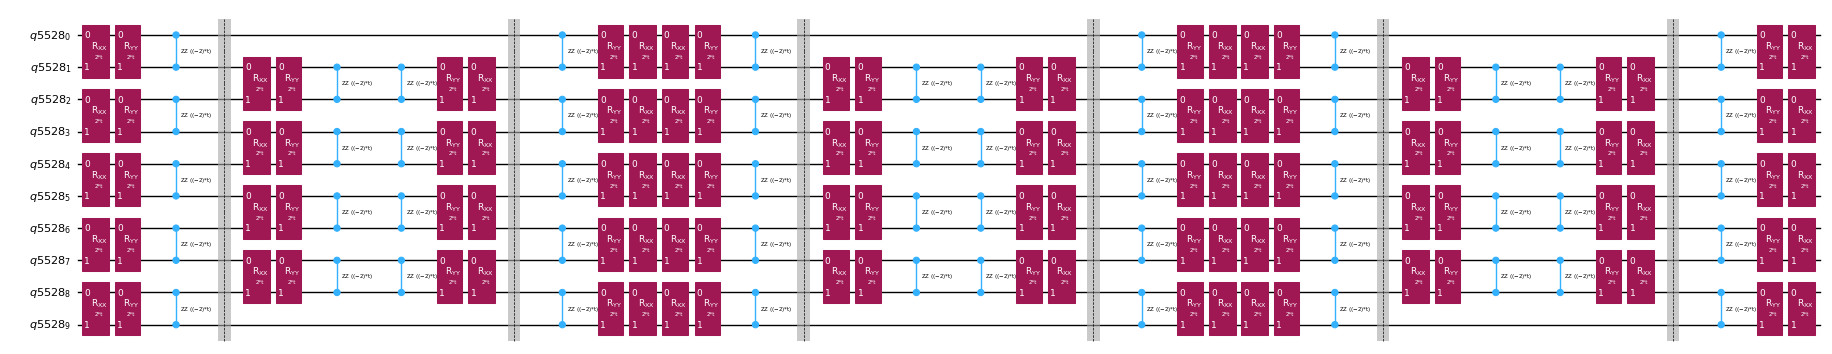

In [51]:
# efficient time evolution block for both sr and mrs case
t = Parameter("t")
qc_evol = build_efficient_time_evolution_circuit(n_qubits, num_trotter_steps, t)
qc_evol.decompose().draw("mpl", fold=-1, scale=0.5)

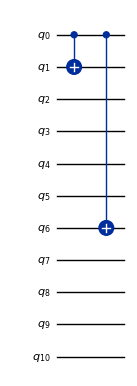

In [52]:
# initial state
from qiskit import QuantumCircuit

def controlled_slater_det_prep(ncas, occ_alpha, occ_beta, anc=0, sys_offset=1):
    """
    Returns a circuit with (1 + 2*ncas) qubits:
      qubit 0 is ancilla (control)
      qubits 1..2*ncas are system

    When ancilla = |1>, prepares the Slater determinant on the system.
    """
    n_sys = 2 * ncas
    qc = QuantumCircuit(1 + n_sys)

    # control each occupied system qubit with ancilla
    for p in occ_alpha:
        qc.cx(anc, sys_offset + p)            # alpha block
    for p in occ_beta:
        qc.cx(anc, sys_offset + ncas + p)     # beta block

    return qc

#LiH
controlled_state_prep = controlled_slater_det_prep(ncas=5, occ_alpha=[0], occ_beta=[0]) # (α0,β0)

# N2
# controlled_state_prep = controlled_slater_det_prep(ncas=6, occ_alpha=[0,1,2], occ_beta=[0,1,2])

# controlled_state_prep = get_krylov_initial_state(n_qubits)
controlled_state_prep.draw("mpl", fold=-1, scale=0.5)

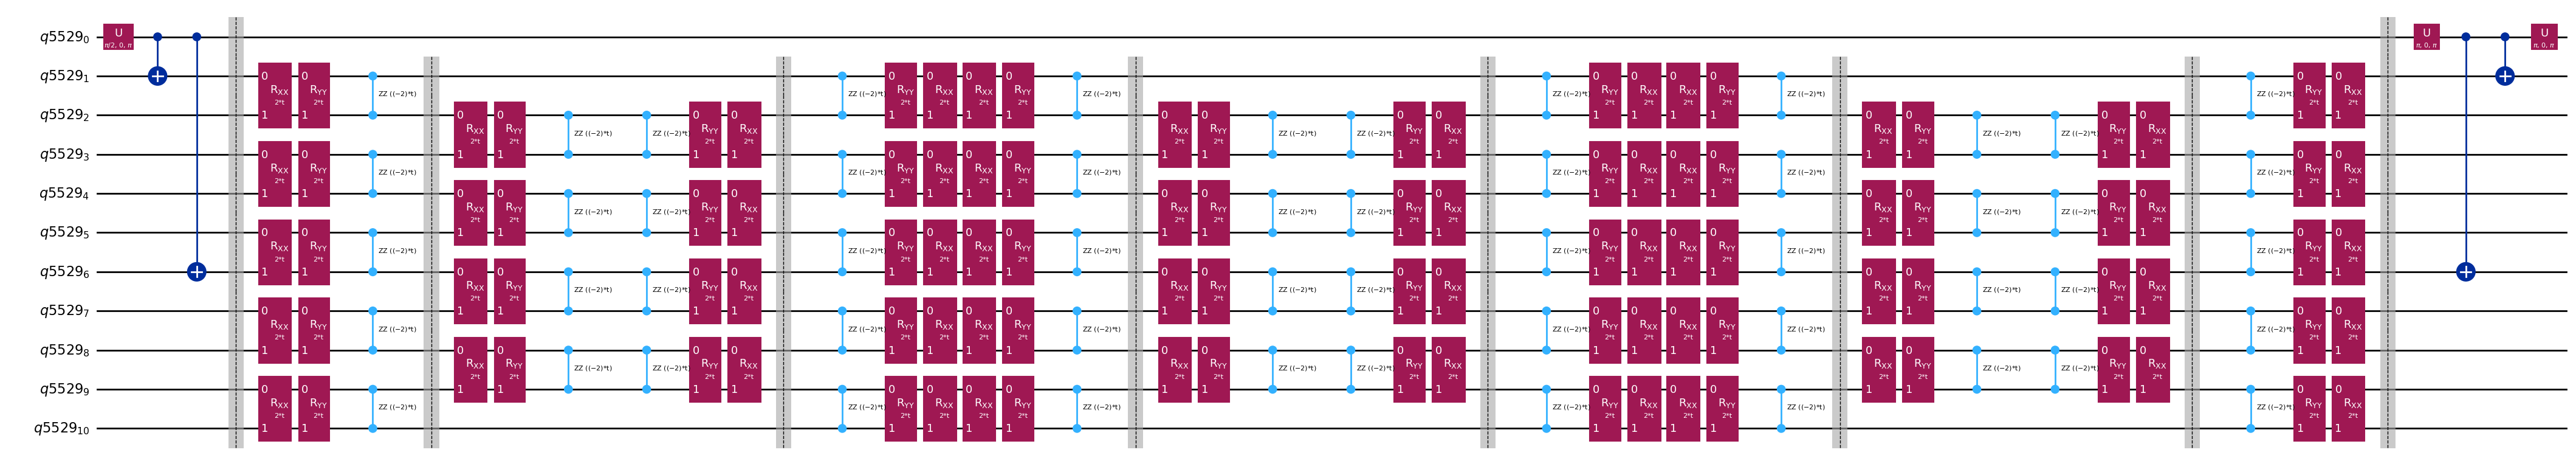

In [53]:
# Hadamard for single ref
parameters = get_parameters_for_template_circuit(krylov_dim, dt_circ)

qc_sr_template = build_modified_hadamard_test_circuit(n_qubits, controlled_state_prep, qc_evol)
qc_sr_template.decompose().draw("mpl", fold=-1)

### 3. Execute using a Qiskit Runtime primitive

In [54]:
backend = AerSimulator()
pm = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend,
    basis_gates=list(backend.target.operation_names),
)

In [55]:
#the SINGLE-REFERENCE circuit transpile
qc_sr_trans = pm.run(qc_sr_template)
print("SR 2Q depth:", qc_sr_trans.depth(lambda x: x[0].num_qubits == 2))
print("SR ops:", qc_sr_trans.count_ops())

SR 2Q depth: 40
SR ops: OrderedDict({'rxx': 54, 'ryy': 54, 'rzz': 54, 'barrier': 8, 'cx': 4, 'x': 2, 'h': 1})


In [56]:
# S observables: X_anc, Y_anc used for single and reused for multi
observables_S = get_observables_S(n_qubits, qc_sr_trans)

# H observables: for each Pauli term Pk, measure Pk ⊗ X_anc and Pk ⊗ Y_anc
observables_H = get_observables_H(H_op, qc_sr_trans)

print("Total observable groups:", len(observables_S + observables_H))

Total observable groups: 554


### 3.1 Execute for single reference

In [57]:
params = np.vstack(parameters).T   # shape (1, krylov_dim-1) but Estimator treats as P points

# Estimate the expectation value for all combinations of
# observables and parameter values, where the pub result will have
# shape (# observables, # parameter values).
pub_sr = (qc_sr_trans, observables_S + observables_H, params)

estimator = AerEstimator()
job_sr = estimator.run([pub_sr], precision=0.0)
results_sr = job_sr.result()[0]

In [58]:
qc_cliff = qc_sr_template.assign_parameters({t: 0})

# Get expectation values
S_expval = get_expectation_values_S(n_qubits, qc_cliff)
print("S_expval(t=0) =", S_expval)

H_expval = get_expectation_values_H(H_op, qc_cliff)
print("H_expval(t=0) =", H_expval)

S_expval(t=0) = (1+0j)
H_expval(t=0) = (-6.888918730180772+0j)


### 3.2 Execute for multiple references

In [59]:
# Create orthogonal reference states
from common.states import get_ref_bitstring_chem

# LiH
ref_bitstrings_ = [
    # 5 paired (closed-shell-like)
    get_ref_bitstring_chem(5, occ_alpha=[0], occ_beta=[0]),
    get_ref_bitstring_chem(5, occ_alpha=[1], occ_beta=[1]),
    get_ref_bitstring_chem(5, occ_alpha=[2], occ_beta=[2]),
    get_ref_bitstring_chem(5, occ_alpha=[3], occ_beta=[3]),
    # get_ref_bitstring_chem(5, occ_alpha=[4], occ_beta=[4]),
    #
    # # 5 open-shell (still (1,1), more varied)
    # get_ref_bitstring_chem(5, occ_alpha=[0], occ_beta=[1]),
    # get_ref_bitstring_chem(5, occ_alpha=[1], occ_beta=[0]),
    # get_ref_bitstring_chem(5, occ_alpha=[0], occ_beta=[2]),
    # get_ref_bitstring_chem(5, occ_alpha=[2], occ_beta=[0]),
    # get_ref_bitstring_chem(5, occ_alpha=[1], occ_beta=[2]),
]

ref_bitstrings_1 = ref_bitstrings_[:1]
ref_bitstrings_2 = ref_bitstrings_[:2]
ref_bitstrings_3 = ref_bitstrings_[:3]
ref_bitstrings_4 = ref_bitstrings_[:4]
# ref_bitstrings_5 = ref_bitstrings_[:5]
# ref_bitstrings_6 = ref_bitstrings_[:6]
# ref_bitstrings_10 = ref_bitstrings_[:10]

print(ref_bitstrings_1)
print("MR refs:", ref_bitstrings_)
print("MR dimension for d=10 N =", d_refs_3*(s+1))

['1000010000']
MR refs: ['1000010000', '0100001000', '0010000100', '0001000010']
MR dimension for d=10 N = 30


In [60]:
# MR-only: build a gate-friendly qc_evol_mr with the SAME structure/time parameter t
t = Parameter("t")
qc_evol_mr = build_efficient_time_evolution_circuit_multi(n_qubits, num_trotter_steps, t)

qc_evol_mr_nb = strip_barriers(qc_evol_mr)

In [61]:
circuits_mr_1, meta_mr_1 = build_multi_ref_circuits(d_refs_1, s, n_qubits, ref_bitstrings_1, qc_evol_mr_nb, t, dt_circ)
circuits_mr_2, meta_mr_2 = build_multi_ref_circuits(d_refs_2, s, n_qubits, ref_bitstrings_2, qc_evol_mr_nb, t, dt_circ)
circuits_mr_3, meta_mr_3 = build_multi_ref_circuits(d_refs_3, s, n_qubits, ref_bitstrings_3, qc_evol_mr_nb, t, dt_circ)
circuits_mr_4, meta_mr_4 = build_multi_ref_circuits(d_refs_4, s, n_qubits, ref_bitstrings_4, qc_evol_mr_nb, t, dt_circ)
# circuits_mr_5, meta_mr_5 = build_multi_ref_circuits(d_refs_5, s, n_qubits, ref_bitstrings_5, qc_evol_mr_nb, t, dt_circ)
# circuits_mr_6, meta_mr_6 = build_multi_ref_circuits(d_refs_6, s, n_qubits, ref_bitstrings_6, qc_evol_mr_nb, t, dt_circ)
# circuits_mr_10, meta_mr_10 = build_multi_ref_circuits(d_refs_10, s, n_qubits, ref_bitstrings_10, qc_evol_mr_nb, t, dt_circ)

qc_mr_trans_list_1 = [pm.run(qc) for qc in circuits_mr_1]
qc_mr_trans_list_2 = [pm.run(qc) for qc in circuits_mr_2]
qc_mr_trans_list_3 = [pm.run(qc) for qc in circuits_mr_3]
qc_mr_trans_list_4 = [pm.run(qc) for qc in circuits_mr_4]
# qc_mr_trans_list_5 = [pm.run(qc) for qc in circuits_mr_5]
# qc_mr_trans_list_6 = [pm.run(qc) for qc in circuits_mr_1]
# qc_mr_trans_list_10 = [pm.run(qc) for qc in circuits_mr_1]


pubs_mr_1 = [(qcT, observables_S + observables_H, None) for qcT in qc_mr_trans_list_1]
pubs_mr_2 = [(qcT, observables_S + observables_H, None) for qcT in qc_mr_trans_list_2]
pubs_mr_3 = [(qcT, observables_S + observables_H, None) for qcT in qc_mr_trans_list_3]
pubs_mr_4 = [(qcT, observables_S + observables_H, None) for qcT in qc_mr_trans_list_4]
# pubs_mr_5 = [(qcT, observables_S + observables_H, None) for qcT in qc_mr_trans_list_5]
# pubs_mr_6 = [(qcT, observables_S + observables_H, None) for qcT in qc_mr_trans_list_6]
# pubs_mr_10 = [(qcT, observables_S + observables_H, None) for qcT in qc_mr_trans_list_10]


job_mr_1 = estimator.run(pubs_mr_1, precision=0.0)
job_mr_2 = estimator.run(pubs_mr_2, precision=0.0)
job_mr_3 = estimator.run(pubs_mr_3, precision=0.0)
job_mr_4 = estimator.run(pubs_mr_4, precision=0.0)
# job_mr_5 = estimator.run(pubs_mr_5, precision=0.0)
# job_mr_6 = estimator.run(pubs_mr_6, precision=0.0)
# job_mr_10 = estimator.run(pubs_mr_10, precision=0.0)

results_mr_1 = job_mr_1.result()
results_mr_2 = job_mr_2.result()
results_mr_3 = job_mr_3.result()
results_mr_4 = job_mr_4.result()
# results_mr_5 = job_mr_5.result()
# results_mr_6 = job_mr_6.result()
# results_mr_10 = job_mr_10.result()

print("MR results entries d=3:", len(results_mr_3))

MR results entries d=3: 900


### 4. Post-process and analyze results


In [62]:
prefactors = [
    np.exp(-1j * sum([c for p, c in H_op.to_list() if "Z" in p]) * i * dt)
    for i in range(1, krylov_dim)
]

In [63]:
S_sr = assemble_S_matrix(S_expval, results_sr, krylov_dim, prefactors)
Matrix(S_sr)

Matrix([
[                                      1.0,  -0.105904096357297 - 0.333422365391326*I, 0.111661523992519 - 0.00594655030125417*I,  0.106696879748795 - 0.0241812391460065*I,  0.0697926609190914 - 0.223887638760765*I, -0.238049918021821 - 0.0832761219886453*I,  -0.171328242655793 + 0.182061942779187*I,   0.186983297890517 + 0.117108121946696*I,  -0.0758357843186222 - 0.11561442591518*I,   0.116022324918931 - 0.276433632333174*I],
[ -0.105904096357297 + 0.333422365391326*I,                                       1.0,  -0.105904096357297 - 0.333422365391326*I, 0.111661523992519 - 0.00594655030125417*I,  0.106696879748795 - 0.0241812391460065*I,  0.0697926609190914 - 0.223887638760765*I, -0.238049918021821 - 0.0832761219886453*I,  -0.171328242655793 + 0.182061942779187*I,   0.186983297890517 + 0.117108121946696*I,  -0.0758357843186222 - 0.11561442591518*I],
[0.111661523992519 + 0.00594655030125417*I,  -0.105904096357297 + 0.333422365391326*I,                                       1.

In [64]:
H_sr = assemble_H_matrix(H_expval, H_op, results_sr, krylov_dim, prefactors)
Matrix(H_sr)

Matrix([
[                        -6.88891873018077,    0.734873649914217 + 2.30011152268233*I, -0.762503118266837 + 0.0380872502081395*I,   -0.74553550154171 + 0.149002883607511*I,   -0.512649268297285 + 1.55245865962604*I,     1.6477113252975 + 0.615010117006389*I,     1.20246325551763 - 1.27566200376718*I,   -1.29132569213959 - 0.793051839025388*I,   0.499011015243269 + 0.791021720688712*I,   -0.781794783292016 + 1.91261171719781*I],
[   0.734873649914217 - 2.30011152268233*I,                         -6.88891873018077,    0.734873649914217 + 2.30011152268233*I, -0.762503118266837 + 0.0380872502081395*I,   -0.74553550154171 + 0.149002883607511*I,   -0.512649268297285 + 1.55245865962604*I,     1.6477113252975 + 0.615010117006389*I,     1.20246325551763 - 1.27566200376718*I,   -1.29132569213959 - 0.793051839025388*I,   0.499011015243269 + 0.791021720688712*I],
[-0.762503118266837 - 0.0380872502081395*I,    0.734873649914217 - 2.30011152268233*I,                         -6.8889187301807

In [65]:
# solve generalized eigenvalue problem for sr case
print("Single ref case:")
gnd_sr_list = solve_generalized_eig(H_sr, S_sr, krylov_dim, threshold=1e-12)

Single ref case:
Estimated ground state energy for d=1:  -6.888918730180772
Estimated ground state energy for d=2:  -6.893932676803428
Estimated ground state energy for d=3:  -6.897527368580619
Estimated ground state energy for d=4:  -6.910743588717505
Estimated ground state energy for d=5:  -6.926116543357711
Estimated ground state energy for d=6:  -6.944099293887571
Estimated ground state energy for d=7:  -6.952526798280893
Estimated ground state energy for d=8:  -6.956223636613005
Estimated ground state energy for d=9:  -6.981928153767118
Estimated ground state energy for d=10:  -7.033617546229314


In [66]:
# for MULTIREFERENCE extract for full H and S matrix
S_mr_1, H_mr_1 = assemble_H_and_S_multiref(d_refs_1, s, meta_mr_1, results_mr_1, H_op)
S_mr_2, H_mr_2 = assemble_H_and_S_multiref(d_refs_2, s, meta_mr_2, results_mr_2, H_op)
S_mr_3, H_mr_3 = assemble_H_and_S_multiref(d_refs_3, s, meta_mr_3, results_mr_3, H_op)
S_mr_4, H_mr_4 = assemble_H_and_S_multiref(d_refs_4, s, meta_mr_4, results_mr_4, H_op)
# S_mr_5, H_mr_5 = assemble_H_and_S_multiref(d_refs_5, s, meta_mr_5, results_mr_5, H_op)
# S_mr_6, H_mr_6 = assemble_H_and_S_multiref(d_refs_6, s, meta_mr_6, results_mr_6, H_op)
# S_mr_10, H_mr_10 = assemble_H_and_S_multiref(d_refs_10, s, meta_mr_10, results_mr_10, H_op)

evals_1  = np.linalg.eigvalsh(S_mr_1)
evals_2  = np.linalg.eigvalsh(S_mr_2)
evals_3  = np.linalg.eigvalsh(S_mr_3)
evals_4  = np.linalg.eigvalsh(S_mr_4)
# evals_5  = np.linalg.eigvalsh(S_mr_5)
# evals_6  = np.linalg.eigvalsh(S_mr_6)
# evals_10 = np.linalg.eigvalsh(S_mr_10)

print("MR S eig d=3 min/max:", evals_3.min(), evals_3.max())
print("MR diag(S) d=3 min/max:", np.real(np.diag(S_mr_3)).min(), np.real(np.diag(S_mr_3)).max())

MR S eig d=3 min/max: 0.002302649211181477 3.939548102935852
MR diag(S) d=3 min/max: 0.9999999999999697 1.0000000000000084


In [67]:
print("Multireference case: d =", d_refs_1)
gnd_mr_list_1 = solve_generalized_eig_multi(
    S_mr_1, H_mr_1, krylov_dim, s, d_refs_1, threshold=1e-12
)

print("Multireference case: d =", d_refs_2)
gnd_mr_list_2 = solve_generalized_eig_multi(
    S_mr_2, H_mr_2, krylov_dim, s, d_refs_2, threshold=1e-12
)

print("Multireference case: d =", d_refs_3)
gnd_mr_list_3 = solve_generalized_eig_multi(
    S_mr_3, H_mr_3, krylov_dim, s, d_refs_3, threshold=1e-12
)

print("Multireference case: d =", d_refs_4)
gnd_mr_list_4 = solve_generalized_eig_multi(
    S_mr_4, H_mr_4, krylov_dim, s, d_refs_4, threshold=1e-12
)

# print("Multireference case: d =", d_refs_5)
# gnd_mr_list_5 = solve_generalized_eig_multi(
#     S_mr_5, H_mr_5, krylov_dim, s, d_refs_5, threshold=1e-12
# )

# print("Multireference case: d =", d_refs_6)
# gnd_mr_list_6 = solve_generalized_eig_multi(
#     S_mr_6, H_mr_6, krylov_dim, s, d_refs_6, threshold=1e-12
# )
#
# print("Multireference case: d =", d_refs_10)
# gnd_mr_list_10 = solve_generalized_eig_multi(
#     S_mr_10, H_mr_10, krylov_dim, s, d_refs_10, threshold=1e-12
# )


Multireference case: d = 1
Estimated ground energy (k=1, dim=1): -6.888918730180773
Estimated ground energy (k=2, dim=2): -7.38638982987252
Estimated ground energy (k=3, dim=3): -7.400599132756609
Estimated ground energy (k=4, dim=4): -7.484799216842687
Estimated ground energy (k=5, dim=5): -7.5590750402807165
Estimated ground energy (k=6, dim=6): -7.589830354448981
Estimated ground energy (k=7, dim=7): -7.609709006159125
Estimated ground energy (k=8, dim=8): -7.676341056353351
Estimated ground energy (k=9, dim=9): -7.7191909829789696
Estimated ground energy (k=10, dim=10): -7.7223844712893355
Multireference case: d = 2
Estimated ground energy (k=1, dim=2): -7.2857588847699475
Estimated ground energy (k=2, dim=4): -7.4273481010261655
Estimated ground energy (k=3, dim=6): -7.458972894483271
Estimated ground energy (k=4, dim=8): -7.567910559099435
Estimated ground energy (k=5, dim=10): -7.598434879772867
Estimated ground energy (k=6, dim=12): -7.645779596720391
Estimated ground energy (k

In [68]:
print("Multireference case: d =3")
print("Diag(S_mr) first 10:", np.real(np.diag(S_mr_3))[:10])
print("||S - S†||:", np.linalg.norm(S_mr_3 - S_mr_3.conj().T))
print("||H - H†||:", np.linalg.norm(H_mr_3 - H_mr_3.conj().T))
I = 1
print("S(I=1,n=0 vs n=1):", S_mr_3[flat(I,0,s), flat(I,1,s)])
print("S(I=1,n=0 vs n=2):", S_mr_3[flat(I,0,s), flat(I,2,s)])

Multireference case: d =3
Diag(S_mr) first 10: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
||S - S†||: 0.0
||H - H†||: 0.0
S(I=1,n=0 vs n=1): (0.2187959222224642+0.05366777707153514j)
S(I=1,n=0 vs n=2): (-0.015962299492166366+0.12748885954315423j)


In [69]:
# gs_en = single_particle_gs(H_op, n_qubits)
import numpy as np

def ground_energy_dense(H):
    # H: qiskit.quantum_info.SparsePauliOp
    Hmat = H.to_matrix()                 # dense (2^n x 2^n)
    evals = np.linalg.eigvalsh(Hmat)     # Hermitian eigs
    return float(evals[0].real)

E0 = ground_energy_dense(H_op)
print("Ground energy:", E0)
# print("Exact single-particle GS energy:", gs_en)

Ground energy: -7.972497020344813


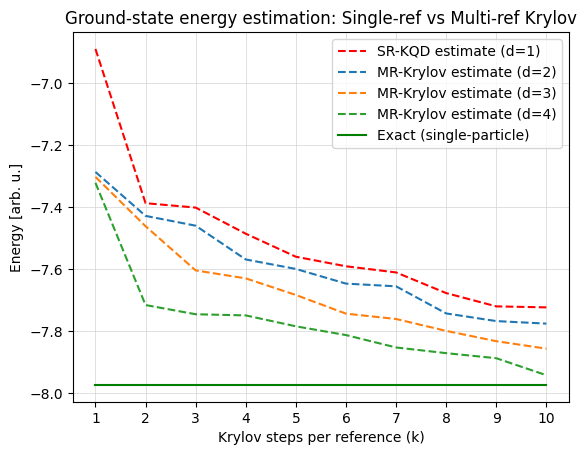

In [70]:
plt.grid(True, which='both', color='lightgray', linestyle='-', linewidth=0.5, alpha=1)
# plt.plot(
#     range(1, krylov_dim + 1),
#     gnd_sr_list,
#     color="red",
#     linestyle="--",
#     label="SR-KQD estimate (d=1)",
# )
# plt.plot(
#     range(1, krylov_dim + 1),
#     gnd_mr_list,
#     color="blue",
#     linestyle="--",
#     label="MR-Krylov estimate (d=3)",
# )

plt.plot(
    range(1, krylov_dim + 1),
    gnd_mr_list_1,
    color="red",
    linestyle="--",
    label="SR-KQD estimate (d=1)",
)

plt.plot(
    range(1, krylov_dim + 1),
    gnd_mr_list_2,
    linestyle="--",
    label="MR-Krylov estimate (d=2)",
)

plt.plot(
    range(1, krylov_dim + 1),
    gnd_mr_list_3,
    linestyle="--",
    label="MR-Krylov estimate (d=3)",
)

plt.plot(
    range(1, krylov_dim + 1),
    gnd_mr_list_4,
    linestyle="--",
    label="MR-Krylov estimate (d=4)",
)

# plt.plot(
#     range(1, krylov_dim + 1),
#     gnd_mr_list_5,
#     linestyle="--",
#     label="MR-Krylov estimate (d=5)",
# )

# plt.plot(
#     range(1, krylov_dim + 1),
#     gnd_mr_list_6,
#     linestyle="--",
#     label="MR-Krylov estimate (d=6)",
# )
#
# plt.plot(
#     range(1, krylov_dim + 1),
#     gnd_mr_list_10,
#     linestyle="--",
#     label="MR-Krylov estimate (d=10)",
# )


plt.plot(
    range(1, krylov_dim + 1),
    [E0] * krylov_dim,
    color="green",
    linestyle="-",
    label="Exact (single-particle)",
)

plt.xticks(range(1, krylov_dim + 1), range(1, krylov_dim + 1))
plt.legend()
plt.xlabel("Krylov steps per reference (k)")
plt.ylabel("Energy [arb. u.]")
plt.title("Ground-state energy estimation: Single-ref vs Multi-ref Krylov")
plt.show()